# Module 3 — Forecasting Apple Stock Prices with an LSTM Network


## Step 1 — Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow: {tf.__version__}")
print(f"NumPy:      {np.__version__}")
print(f"Pandas:     {pd.__version__}")

TensorFlow: 2.20.0
NumPy:      2.0.2
Pandas:     2.2.2


## Step 2 — Load the data and take a first look

The dataset is five years of daily AAPL price data pulled from Yahoo Finance. Each row is one trading day.

In [2]:
github_url = 'https://raw.githubusercontent.com/BPALAN-USD/AAI511/main/M3-AAPL.csv'

df = pd.read_csv(github_url, parse_dates=['Date'])

#df = pd.read_csv('M3-AAPL.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f"Date range: {df['Date'].min().date()}  →  {df['Date'].max().date()}")
print(f"Trading days: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
df.head(10)

Date range: 2019-05-28  →  2024-05-24
Trading days: 1259
Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


,Date,Open,High,Low,Close,Adj Close,Volume
0,2019-05-28,44.730000,45.147499,44.477501,44.557499,43.002316,111792800
1,2019-05-29,44.105000,44.837502,44.000000,44.345001,42.797237,113924800
2,2019-05-30,44.487499,44.807499,44.167500,44.575001,43.019211,84873600
3,2019-05-31,44.057499,44.497501,43.747501,43.767502,42.239895,108174400
4,2019-06-03,43.900002,44.480000,42.567501,43.325001,41.812828,161584400
5,2019-06-04,43.860001,44.957500,43.630001,44.910000,43.342510,123872000
6,2019-06-05,46.070000,46.247501,45.285000,45.634998,44.042213,119093600
7,2019-06-06,45.770000,46.367500,45.537498,46.305000,44.688820,90105200
8,2019-06-07,46.627499,47.980000,46.442501,47.537498,45.878304,122737600
9,2019-06-10,47.952499,48.842499,47.904999,48.145000,46.464611,104883600


In [3]:
# basic stats — sanity check before doing anything
df.describe().round(2)

,Date,Open,High,Low,Close,Adj Close,Volume
count,1259,1259.00,1259.00,1259.00,1259.00,1259.00,1.259000e+03
mean,2021-11-23 15:33:18.729150208,133.65,135.15,132.26,133.77,132.11,9.655618e+07
min,2019-05-28 00:00:00,43.86,44.48,42.57,43.33,41.81,2.404830e+07
25%,2020-08-24 12:00:00,112.49,113.73,110.00,112.06,109.64,6.313855e+07
50%,2021-11-22 00:00:00,143.80,146.22,142.54,144.29,142.54,8.347440e+07
75%,2023-02-23 12:00:00,169.35,171.01,168.15,169.30,168.30,1.131188e+08
max,2024-05-24 00:00:00,198.02,199.62,197.00,198.11,197.59,4.265100e+08
std,NaN,42.76,43.06,42.44,42.76,43.07,5.190515e+07


In [4]:
# check for nulls — stock data from Yahoo Finance is usually clean but worth verifying
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


## Step 3 — Exploratory data analysis

Before building anything, it helps to *see* the data. AAPL had an incredible run from 2019 to 2024 — we should understand the scale of that move and how volatile daily returns were.

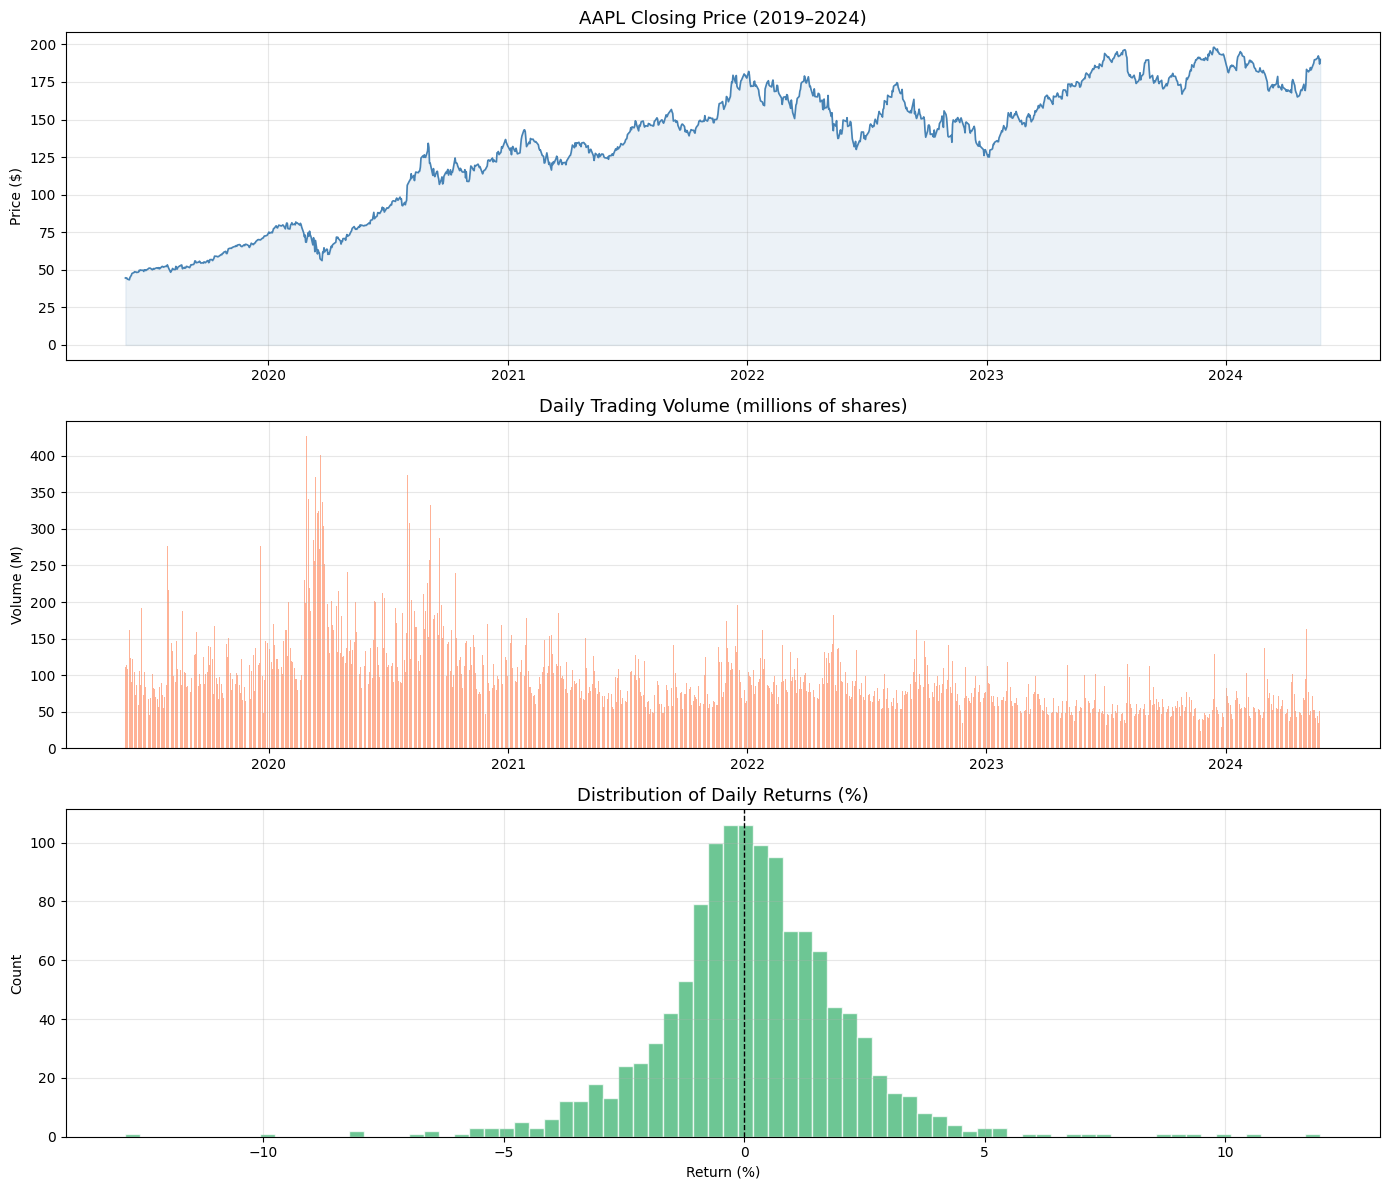

Mean daily return:  0.135%
Std  daily return:  1.998%
Max single-day gain:  11.98%
Max single-day loss:  -12.86%


In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# closing price over time
axes[0].plot(df['Date'], df['Close'], color='steelblue', linewidth=1.2)
axes[0].set_title('AAPL Closing Price (2019–2024)', fontsize=13)
axes[0].set_ylabel('Price ($)')
axes[0].xaxis.set_major_locator(mdates.YearLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0].grid(alpha=0.3)
axes[0].fill_between(df['Date'], df['Close'], alpha=0.1, color='steelblue')

# daily volume
axes[1].bar(df['Date'], df['Volume'] / 1e6, color='coral', alpha=0.6, width=1)
axes[1].set_title('Daily Trading Volume (millions of shares)', fontsize=13)
axes[1].set_ylabel('Volume (M)')
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].grid(alpha=0.3)

# daily returns distribution
df['daily_return'] = df['Close'].pct_change() * 100
axes[2].hist(df['daily_return'].dropna(), bins=80, color='mediumseagreen', alpha=0.75, edgecolor='white')
axes[2].axvline(0, color='black', linestyle='--', linewidth=1)
axes[2].set_title('Distribution of Daily Returns (%)', fontsize=13)
axes[2].set_xlabel('Return (%)')
axes[2].set_ylabel('Count')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Mean daily return:  {df['daily_return'].mean():.3f}%")
print(f"Std  daily return:  {df['daily_return'].std():.3f}%")
print(f"Max single-day gain:  {df['daily_return'].max():.2f}%")
print(f"Max single-day loss:  {df['daily_return'].min():.2f}%")

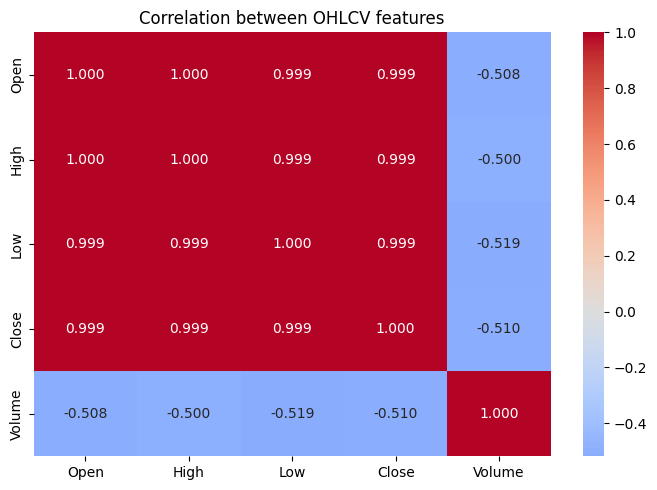

In [6]:
# correlation between OHLCV features
price_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
plt.figure(figsize=(7, 5))
sns.heatmap(df[price_cols].corr(), annot=True, fmt='.3f', cmap='coolwarm', center=0)
plt.title('Correlation between OHLCV features')
plt.tight_layout()
plt.show()

The Open, High, Low, and Close prices are all extremely correlated (>0.99) with each other — which makes sense because they all track the same underlying stock. Volume is less correlated with price.

**Feature selection decision:** We'll use `Close` as the primary input feature. It's the standard benchmark in stock forecasting literature, and adding the other price columns would mostly be redundant. We'll also keep `Volume` as a secondary feature to give the model some sense of market activity.

## Step 4 — Feature selection and normalization

Neural networks are sensitive to input scale. A `Close` price of ~$180 and a `Volume` of 100 million are on completely different scales — without normalization, the model would treat the volume signal as astronomically more important just because the numbers are bigger.

We use **MinMaxScaler** (scale to [0, 1]) instead of StandardScaler here because:
- Stock prices don't follow a normal distribution, so Z-score normalization is less appropriate
- MinMax keeps all values in a bounded range, which is better for LSTM sigmoid/tanh activations
- It's standard practice for time-series regression tasks

In [7]:
# select features
features = ['Close', 'Volume']
data = df[features].values

print(f"Feature matrix shape: {data.shape}")
print(f"\nBefore scaling — Close range: ${data[:, 0].min():.2f} to ${data[:, 0].max():.2f}")
print(f"Before scaling — Volume range: {data[:, 1].min():,.0f} to {data[:, 1].max():,.0f}")

Feature matrix shape: (1259, 2)

Before scaling — Close range: $43.33 to $198.11
Before scaling — Volume range: 24,048,300 to 426,510,000


In [8]:
# fit the scaler on the FULL dataset
# we keep a separate scaler for Close so we can invert predictions back to dollar values
scaler_all   = MinMaxScaler(feature_range=(0, 1))
scaler_close = MinMaxScaler(feature_range=(0, 1))

data_scaled       = scaler_all.fit_transform(data)
close_scaled_only = scaler_close.fit_transform(data[:, 0].reshape(-1, 1))

print("After scaling — first 5 rows:")
pd.DataFrame(data_scaled[:5], columns=features).round(4)

After scaling — first 5 rows:


,Close,Volume
0,0.0080,0.2180
1,0.0066,0.2233
2,0.0081,0.1511
3,0.0029,0.2090
4,0.0000,0.3417


## Step 5 — Build sliding-window sequences

RNNs don't consume rows of data one at a time — they consume **sequences**. We use a sliding window: for each day $t$, the model sees the previous `look_back` days and tries to predict the close price on day $t$.

```
Window size = 60 (about 3 trading months)

[day 1 … day 60]  →  predict day 61
[day 2 … day 61]  →  predict day 62
        ...
```

Choosing 60 days is a common choice for daily stock data — it gives the model enough context to pick up on trends and short-term momentum without being too short (noisy) or too long (computationally expensive).

In [9]:
LOOK_BACK = 60   # number of past days the model looks at

def create_sequences(data_array, close_array, look_back):
    """create (X, y) pairs with a sliding window over the time series"""
    X, y = [], []
    for i in range(look_back, len(data_array)):
        X.append(data_array[i - look_back : i])  # shape: (look_back, n_features)
        y.append(close_array[i, 0])              # predict today's Close
    return np.array(X), np.array(y)

X_all, y_all = create_sequences(data_scaled, close_scaled_only, LOOK_BACK)

print(f"Total sequences:       {len(X_all)}")
print(f"Each X sample shape:   {X_all[0].shape}  (look_back days × n_features)")
print(f"Each y value:          scalar (next-day Close, MinMax-scaled)")

Total sequences:       1199
Each X sample shape:   (60, 2)  (look_back days × n_features)
Each y value:          scalar (next-day Close, MinMax-scaled)


## Step 6 — Train / test split

**Important:** we cannot shuffle time-series data. The whole point is that the model learns from the *order* of events. We split chronologically — the first 80% of sequences for training, the last 20% for testing.

Shuffling would let future data leak into training, making the model look better than it actually is on unseen data.

In [10]:
split_idx = int(len(X_all) * 0.80)

X_train, X_test = X_all[:split_idx],  X_all[split_idx:]
y_train, y_test = y_all[:split_idx],  y_all[split_idx:]

# keep track of which dates correspond to test predictions (needed for plotting)
test_dates = df['Date'].iloc[LOOK_BACK + split_idx:].values

print(f"Training sequences:  {X_train.shape[0]}")
print(f"  from: {df['Date'].iloc[LOOK_BACK].date()}  →  {df['Date'].iloc[LOOK_BACK + split_idx - 1].date()}")
print(f"\nTest sequences:      {X_test.shape[0]}")
print(f"  from: {df['Date'].iloc[LOOK_BACK + split_idx].date()}  →  {df['Date'].iloc[-1].date()}")
print(f"\nX_train shape: {X_train.shape}   →  (samples, timesteps, features)")
print(f"X_test  shape: {X_test.shape}")

Training sequences:  959
  from: 2019-08-21  →  2023-06-12

Test sequences:      240
  from: 2023-06-13  →  2024-05-24

X_train shape: (959, 60, 2)   →  (samples, timesteps, features)
X_test  shape: (240, 60, 2)


## Step 7 — Build the LSTM model

The architecture has two stacked LSTM layers followed by two Dense layers:

```
Input  (60 timesteps × 2 features)
  ↓
LSTM(128 units, return_sequences=True)   ← first LSTM passes its full output sequence to the next
  ↓
Dropout(0.2)                             ← randomly zero out 20% of neurons during training
  ↓
LSTM(64 units)                           ← second LSTM returns only the final hidden state
  ↓
Dropout(0.2)
  ↓
Dense(32, relu)                          ← linear combination of LSTM output
  ↓
Dense(1)                                 ← single scalar: predicted next-day Close (scaled)
```

**Why two LSTM layers?** The first layer learns low-level temporal patterns (short-term momentum, day-to-day noise). The second layer abstracts over those patterns to capture higher-level trends. Stacking works well for stock data where patterns exist at multiple time scales.

**Why Dropout?** Stock data is noisy. Without regularization the model memorizes training sequences instead of learning generalizable patterns.

In [11]:
n_timesteps = X_train.shape[1]   # 60
n_features  = X_train.shape[2]   # 2 (Close, Volume)

def build_lstm_model():
    model = keras.Sequential([
        layers.Input(shape=(n_timesteps, n_features)),

        # first LSTM — return_sequences=True passes the full sequence to the next LSTM
        layers.LSTM(128, return_sequences=True),
        layers.Dropout(0.2),

        # second LSTM — return_sequences=False (default), returns only the final state
        layers.LSTM(64),
        layers.Dropout(0.2),

        layers.Dense(32, activation='relu'),
        layers.Dense(1)   # regression output — no activation
    ], name='AAPL_LSTM')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mean_squared_error'
    )
    return model

model = build_lstm_model()
model.summary()

Model: "AAPL_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │        67,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,593 (463.25 KB)

 Trainable params: 118,593 (463.25 KB)

 Non-trainable params: 0 (0.00 B)

## Step 8 — Train the model

We train for up to 100 epochs with early stopping: if the validation loss doesn't improve for 15 consecutive epochs, training stops and the best weights are restored. We also use a learning rate scheduler — when the loss plateaus, halving the learning rate often lets the optimizer find a better minimum.

In [12]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,       # halve the learning rate when stuck
    patience=7,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.10,   # hold out 10% of training data for validation
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print(f"\nTraining stopped at epoch {len(history.history['loss'])}")
print(f"Best validation loss: {min(history.history['val_loss']):.6f}")

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - loss: 0.0392 - val_loss: 0.0064 - learning_rate: 0.0010
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0053 - val_loss: 0.0011 - learning_rate: 0.0010
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0037 - val_loss: 6.7765e-04 - learning_rate: 0.0010
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0032 - val_loss: 0.0029 - learning_rate: 0.0010
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0030 - val_loss: 0.0019 - learning_rate: 0.0010
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0028 - val_loss: 0.0025 - learning_rate: 0.0010
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0029 - val_loss: 5.7936e-04 - learning_rate: 0.0010
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0031 - val_loss: 0.0016 - learning_rate: 0.0010
Epoch 9/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0025 - val_loss: 0.0011 - learning_rate: 0.0010
Ep

## Step 9 — Plot training curves

Training loss should decrease steadily. The validation loss tells us whether the model is generalizing — if it starts rising while training loss keeps falling, the model is overfitting.

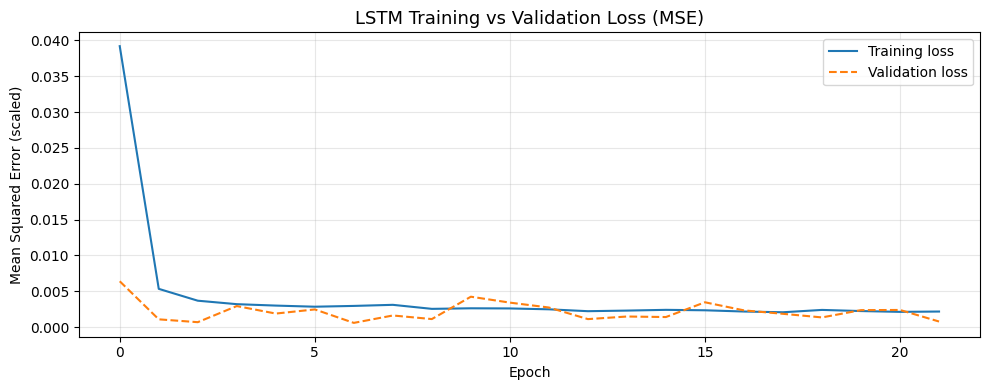

In [13]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Training loss',   linewidth=1.5)
plt.plot(history.history['val_loss'], label='Validation loss', linewidth=1.5, linestyle='--')
plt.title('LSTM Training vs Validation Loss (MSE)', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (scaled)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 10 — Evaluate predictions on the test set

Now we run the model on sequences it has never seen (the last 20% of the data) and compare its predictions against what actually happened. We invert the MinMax scaling so we can report errors in actual dollar terms.

In [14]:
# make predictions
y_pred_scaled = model.predict(X_test, verbose=0)

# invert scaling back to actual dollar prices
y_pred_actual = scaler_close.inverse_transform(y_pred_scaled)
y_test_actual = scaler_close.inverse_transform(y_test.reshape(-1, 1))

# compute error metrics
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mae  = mean_absolute_error(y_test_actual, y_pred_actual)
mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100

print("Test Set Performance Metrics")
print("-" * 40)
print(f"RMSE  (Root Mean Squared Error): ${rmse:.2f}")
print(f"MAE   (Mean Absolute Error):     ${mae:.2f}")
print(f"MAPE  (Mean Abs Pct Error):      {mape:.2f}%")

Test Set Performance Metrics
----------------------------------------
RMSE  (Root Mean Squared Error): $5.60
MAE   (Mean Absolute Error):     $4.65
MAPE  (Mean Abs Pct Error):      2.58%


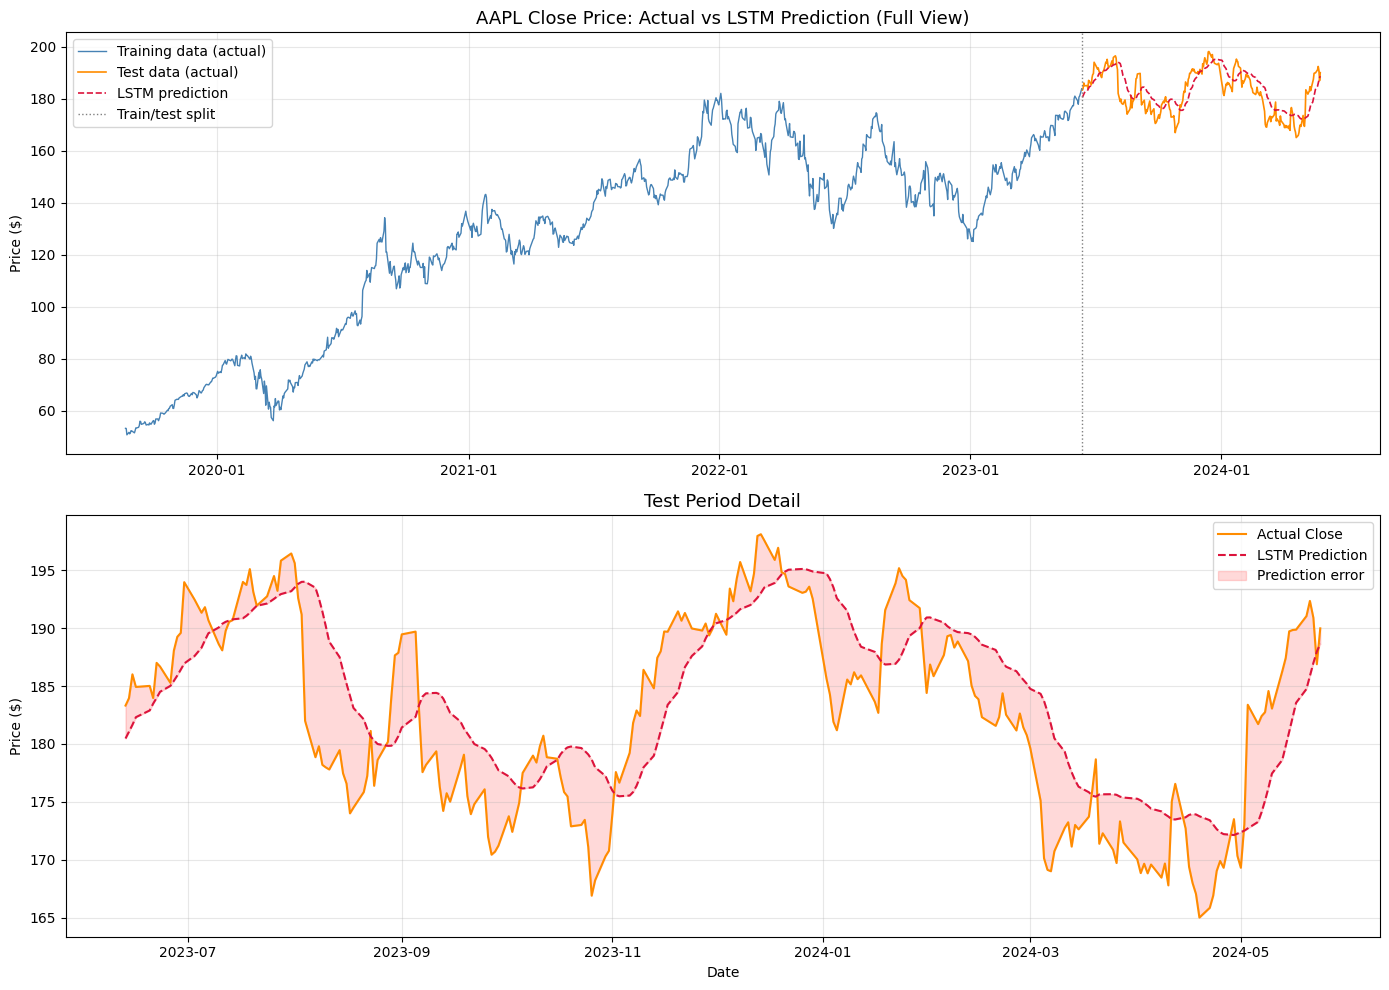

In [15]:
# plot predicted vs actual
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# full view: training period + test predictions
train_actual_prices = df['Close'].iloc[LOOK_BACK : LOOK_BACK + split_idx].values
train_dates         = df['Date'].iloc[LOOK_BACK : LOOK_BACK + split_idx].values

ax1.plot(train_dates, train_actual_prices, label='Training data (actual)',  color='steelblue',  linewidth=1)
ax1.plot(test_dates,  y_test_actual,       label='Test data (actual)',       color='darkorange',  linewidth=1.2)
ax1.plot(test_dates,  y_pred_actual,       label='LSTM prediction',          color='crimson',     linewidth=1.2, linestyle='--')
ax1.axvline(test_dates[0], color='gray', linestyle=':', linewidth=1, label='Train/test split')
ax1.set_title('AAPL Close Price: Actual vs LSTM Prediction (Full View)', fontsize=13)
ax1.set_ylabel('Price ($)')
ax1.legend(loc='upper left')
ax1.grid(alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# zoom: just the test period
ax2.plot(test_dates, y_test_actual, label='Actual Close',    color='darkorange', linewidth=1.5)
ax2.plot(test_dates, y_pred_actual, label='LSTM Prediction', color='crimson',    linewidth=1.5, linestyle='--')
ax2.fill_between(
    test_dates,
    y_test_actual.flatten(),
    y_pred_actual.flatten(),
    alpha=0.15, color='red', label='Prediction error'
)
ax2.set_title('Test Period Detail', fontsize=13)
ax2.set_xlabel('Date')
ax2.set_ylabel('Price ($)')
ax2.legend()
ax2.grid(alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.show()

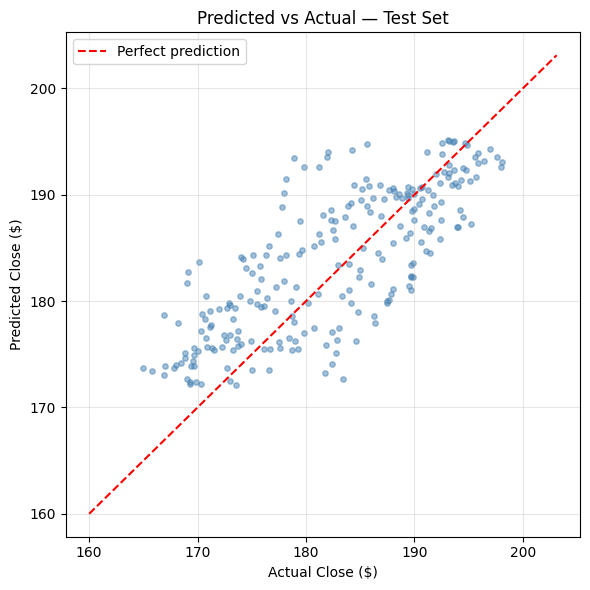

In [16]:
# scatter plot: predicted vs actual — a perfect model would be a diagonal line
plt.figure(figsize=(6, 6))
plt.scatter(y_test_actual, y_pred_actual, alpha=0.5, s=15, color='steelblue')

min_val = min(y_test_actual.min(), y_pred_actual.min()) - 5
max_val = max(y_test_actual.max(), y_pred_actual.max()) + 5
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect prediction')

plt.xlabel('Actual Close ($)')
plt.ylabel('Predicted Close ($)')
plt.title('Predicted vs Actual — Test Set')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 11 — Forecast future stock prices

This is the most interesting part: we take the last 60 days of known data and use the trained model to iteratively predict the next N trading days. Each predicted price becomes part of the input window for the next prediction.

**Important caveat:** This type of recursive multi-step forecast compounds errors — each prediction is based on previous predictions, not ground truth. The further out we go, the less reliable the forecast becomes. Think of it as directional guidance rather than a precise price target.

In [17]:
FORECAST_DAYS = 30   # predict the next 30 trading days (~6 weeks)

# start from the last 60-day window in the full scaled dataset
last_window = data_scaled[-LOOK_BACK:].copy()   # shape: (60, 2)

future_predictions = []

for _ in range(FORECAST_DAYS):
    # reshape for model input: (1, look_back, n_features)
    x_input = last_window.reshape(1, LOOK_BACK, n_features)

    # predict next day's Close (scaled)
    pred_scaled = model.predict(x_input, verbose=0)[0, 0]
    future_predictions.append(pred_scaled)

    # build the next row: predicted Close + hold Volume at last known level
    # (volume is hard to predict independently; this is a reasonable simplification)
    last_volume = last_window[-1, 1]
    new_row     = np.array([pred_scaled, last_volume])

    # slide the window forward by one day
    last_window = np.vstack([last_window[1:], new_row])

# invert the Close scaling back to dollars
future_prices = scaler_close.inverse_transform(
    np.array(future_predictions).reshape(-1, 1)
)

# generate business day dates for the forecast horizon
last_known_date = df['Date'].iloc[-1]
future_dates    = pd.bdate_range(start=last_known_date + pd.Timedelta(days=1),
                                 periods=FORECAST_DAYS)

print(f"Forecast period:   {future_dates[0].date()} → {future_dates[-1].date()}")
print(f"Last known Close:  ${df['Close'].iloc[-1]:.2f}")
print(f"Day 1 forecast:    ${future_prices[0, 0]:.2f}")
print(f"Day 30 forecast:   ${future_prices[-1, 0]:.2f}")

Forecast period:   2024-05-27 → 2024-07-05
Last known Close:  $189.98
Day 1 forecast:    $189.24
Day 30 forecast:   $193.33


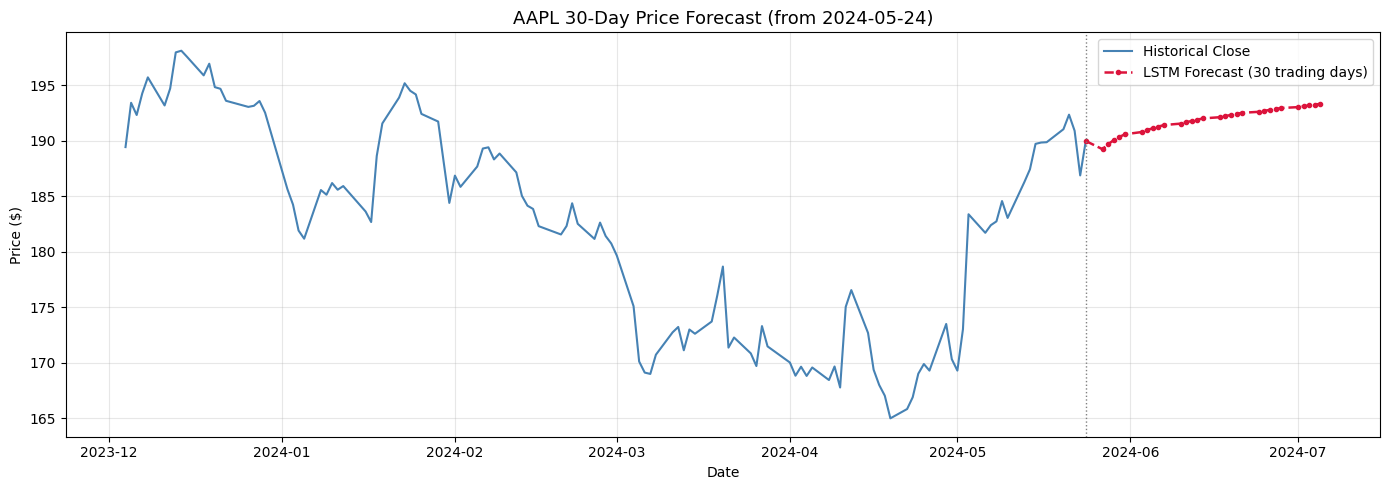

In [18]:
# plot the forecast alongside recent actual data
recent_days = 120   # show the last 120 trading days for context
recent_df   = df.tail(recent_days)

plt.figure(figsize=(14, 5))
plt.plot(recent_df['Date'], recent_df['Close'],
         label='Historical Close', color='steelblue', linewidth=1.5)

# connect the last known point to the forecast so the line is continuous
bridge_dates  = [recent_df['Date'].iloc[-1]] + list(future_dates)
bridge_prices = [recent_df['Close'].iloc[-1]] + list(future_prices.flatten())

plt.plot(bridge_dates, bridge_prices,
         label=f'LSTM Forecast ({FORECAST_DAYS} trading days)',
         color='crimson', linewidth=1.8, linestyle='--', marker='o', markersize=3)

plt.axvline(recent_df['Date'].iloc[-1], color='gray', linestyle=':', linewidth=1)
plt.title(f'AAPL 30-Day Price Forecast (from {last_known_date.date()})', fontsize=13)
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
# show the forecast as a table
forecast_df = pd.DataFrame({
    'Date':            future_dates,
    'Predicted Close': future_prices.flatten().round(2)
})
forecast_df['Change from Previous'] = forecast_df['Predicted Close'].diff().round(2)
forecast_df.loc[0, 'Change from Previous'] = round(
    forecast_df['Predicted Close'].iloc[0] - df['Close'].iloc[-1], 2
)
forecast_df.index = range(1, FORECAST_DAYS + 1)
forecast_df.index.name = 'Day'
forecast_df

,Date,Predicted Close,Change from Previous
Day,,,
1,2024-05-27,189.240005,-0.74
2,2024-05-28,189.690002,0.45
3,2024-05-29,190.050003,0.36
4,2024-05-30,190.339996,0.29
5,2024-05-31,190.580002,0.24
6,2024-06-03,190.789993,0.21
7,2024-06-04,190.970001,0.18
8,2024-06-05,191.130005,0.16
9,2024-06-06,191.279999,0.15


## Step 12 — Summary and Reflection

### What we built

A two-layer stacked LSTM trained on five years of AAPL daily price data (May 2019 – May 2024). The model takes a 60-day rolling window of Close price and Volume as input and predicts the next day's closing price.

### How LSTM addresses the vanishing gradient problem

A standard RNN updates its hidden state using a simple tanh transformation at each time step. When the error gradient is backpropagated through 60+ steps, it gets multiplied by the same weight matrix 60+ times — if those weights are slightly less than 1, the gradient vanishes exponentially and the model stops learning long-range dependencies.

LSTMs introduce three learnable gates:
- **Forget gate** — decides what to discard from cell state
- **Input gate** — decides what new information to write into cell state
- **Output gate** — decides what to expose as the hidden state at this step

The **cell state** $C_t$ flows through the network with only additive operations (no repeated multiplication), which keeps gradients from vanishing. This allows the model to retain relevant patterns from 30, 40, or 60 days ago — which matters a lot for detecting multi-week stock trends.

### Key design choices

| Decision | Rationale |
|----------|-----------|
| MinMaxScaler over StandardScaler | Stock prices aren't Gaussian; bounded [0,1] range works better with LSTM activations |
| 60-day look-back window | ~3 months of context; balances short-term noise with trend signal |
| Stacked LSTM (128 → 64) | First layer extracts local temporal features; second abstracts higher-level trends |
| Dropout (0.2) | Reduces overfitting on noisy financial data |
| Temporal train/test split | Prevents data leakage — shuffling would be a methodological error |
| Adam optimizer | Adaptive learning rates converge faster than vanilla SGD on LSTMs |
| ReduceLROnPlateau callback | Automatically halves learning rate when training stalls, finding better local minima |

### Limitations

This model is trained only on price and volume — it has no awareness of earnings reports, Fed rate decisions, macroeconomic data, or any other market-moving events. Real quantitative systems combine technical indicators with alternative data sources like earnings transcripts, analyst sentiment, and cross-asset signals.

The recursive 30-day forecast also compounds prediction error at each step: each day's prediction is based on previous predictions rather than ground truth, so the uncertainty grows non-linearly. Day 30 should be treated as a rough directional estimate, not a price target.